# 03 — NLP Analysis: Text Preprocessing, NER & Topic Modeling
### Social Media Behavioral Profiling Pipeline

**Goal:** Extract behavioral signals and latent topic structure from tweet text using NLP techniques, demonstrating a scalable approach to content-based user profiling applicable to platform safety contexts.

**Pipeline:**
1. **Text Preprocessing** — URL removal, punctuation stripping, tokenization, stop word removal
2. **Lemmatization** — Reduce tokens to base dictionary forms
3. **Word Frequency Analysis** — Identify dominant terms across the corpus
4. **Named Entity Recognition (NER)** — Extract and categorize named entities (organizations, places, people/things) using spaCy
5. **Topic Modeling (LDA)** — Surface latent discourse clusters via Gensim

**Input:** `trump_tweets.csv` (generated in `01_data_collection.ipynb`)

## Imports

In [1]:
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import spacy
import en_core_web_sm
from collections import Counter

from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Download required NLTK assets (safe to re-run)
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)

True

## Load Data

In [2]:
df = pd.read_csv("trump_tweets.csv")
df["date"] = pd.to_datetime(df["date"])
print(f"Dataset: {len(df):,} tweets")
df.head()

Dataset: 10,000 tweets


,favorites,date,isDeleted,id,text,retweets,device,isRetweet,isFlagged
0,639463,1970-01-01 00:26:50.120668,False,1347569870578266115,"To all of those who have asked, I will not be ...",79113,Twitter for iPhone,False,NaN
1,535831,1970-01-01 00:26:50.117198,False,1347555316863553542,"The 75,000,000 great American Patriots who vot...",89895,Twitter for iPhone,False,NaN
2,650194,1970-01-01 00:26:50.064624,False,1347334804052844550,https://t.co/csX07ZVWGe,130040,Twitter Media Studio,False,NaN
3,0,1970-01-01 00:26:49.974064,True,1346954970910707712,These are the things and events that happen wh...,0,Twitter for iPhone,False,NaN
4,0,1970-01-01 00:26:49.967844,True,1346928882595885058,https://t.co/Pm2PKV0Fp3,0,Twitter for iPhone,False,NaN


---
## Part 1: Text Preprocessing

### Step 1 — Basic Cleaning

We apply basic cleaning to the raw tweet text:
- Remove URLs
- Strip punctuation
- Remove `@mentions` and `#hashtag` symbols
- Remove numeric characters
- Lowercase all text

**Note on NER ordering:** NER (spaCy) works best on text that is as close to natural language as possible (i.e. before lemmatization or stop word removal). We therefore keep a `cleaned_text` column (basic cleaning only) specifically for NER, and a fully preprocessed `lemmatized_text` column for word frequency analysis and topic modeling.

In [3]:
def clean_tweet(tweet: str) -> str:
    """
    Apply basic cleaning to a raw tweet string.

    Removes URLs, punctuation, @mentions, hashtag symbols,
    digits, and lowercases the result.

    Parameters
    ----------
    tweet : str
        Raw tweet text.

    Returns
    -------
    str
        Cleaned tweet text.
    """
    tweet = re.sub(r"http\S+|www\S+|https\S+", "", tweet, flags=re.MULTILINE)
    tweet = tweet.translate(str.maketrans("", "", string.punctuation))
    tweet = re.sub(r"\@\w+|\#", "", tweet)
    tweet = re.sub(r"\d+", "", tweet)
    return tweet.lower()

df["cleaned_text"] = df["text"].apply(clean_tweet)
df["cleaned_text"].head()

0    to all of those who have asked i will not be g...
1    the  great american patriots who voted for me ...
2                                                     
3    these are the things and events that happen wh...
4                                                     
Name: cleaned_text, dtype: object

### Step 2 — Tokenization & Stop Word Removal

Tokenize each cleaned tweet and remove common English stop words (i.e., "the", "is", "and") that carry no behavioral signal.

In [4]:
stop_words = set(stopwords.words("english"))

def tokenize_tweet(tweet: str) -> list[str]:
    """
    Tokenize a cleaned tweet and remove stop words.

    Parameters
    ----------
    tweet : str
        Cleaned tweet text.

    Returns
    -------
    list[str]
        List of meaningful tokens.
    """
    tokens = word_tokenize(tweet)
    return [word for word in tokens if word not in stop_words]

df["tokenized_text"] = df["cleaned_text"].apply(tokenize_tweet)
df["tokenized_text"].head()

0            [asked, going, inauguration, january, th]
1    [great, american, patriots, voted, america, fi...
2                                                   []
3    [things, events, happen, sacred, landslide, el...
4                                                   []
Name: tokenized_text, dtype: object

### Step 3 — Lemmatization

We reduce tokens to their base dictionary form (lemma) using NLTK's `WordNetLemmatizer`.

**Lemmatization vs. Stemming:**
- *Stemming* strips prefixes/suffixes via rules (fast, but can produce non-words)
- *Lemmatization* uses vocabulary and morphological analysis to produce valid dictionary words (more accurate)

We choose lemmatization for higher-quality features in downstream analysis.

**Note:** We observed that aggressive post-NER lemmatization can distort entity terms (i.e., "us" -> "u"). We therefore apply lemmatization here for word frequency and topic modeling only. NER runs on `cleaned_text` (basic cleaning only).

In [5]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(tokens: list[str]) -> list[str]:
    """
    Lemmatize a list of tokens.

    Parameters
    ----------
    tokens : list[str]
        Tokenized and stop-word-filtered tweet.

    Returns
    -------
    list[str]
        Lemmatized tokens.
    """
    return [lemmatizer.lemmatize(token) for token in tokens]

df["lemmatized_text"] = df["tokenized_text"].apply(lemmatize_text)

# Concatenated string version for any models that need raw text input
df["clean_concat_text"] = df["lemmatized_text"].apply(lambda x: " ".join(x))

df["lemmatized_text"].head()

0            [asked, going, inauguration, january, th]
1    [great, american, patriot, voted, america, fir...
2                                                   []
3    [thing, event, happen, sacred, landslide, elec...
4                                                   []
Name: lemmatized_text, dtype: object

---
## Part 2: Word Frequency Analysis

We flatten all lemmatized tokens into a single word list, strip any remaining non-alphanumeric characters, and count term frequencies to identify the most prominent topics in the corpus.

In [6]:
def flatten_tokens(token_lists: pd.Series) -> list[str]:
    """
    Flatten a Series of token lists into a single word list,
    stripping residual non-alphanumeric characters and empty strings.

    Parameters
    ----------
    token_lists : pd.Series
        Series where each element is a list of tokens.

    Returns
    -------
    list[str]
        Flat list of cleaned words.
    """
    words = []
    for sublist in token_lists:
        words.extend([word.strip() for word in sublist])
    words = [re.sub(r"[^A-Za-z0-9]+", "", w) for w in words]
    return [w for w in words if w.strip()]

all_words = flatten_tokens(df["lemmatized_text"])
print(f"Total tokens: {len(all_words):,}")

Total tokens: 117,354


In [7]:
words_series = pd.Series(all_words)
raw_counts = words_series.value_counts()

# 'rt' indicates a retweet prefix and 'realdonaldtrump' indicates a mention —
# neither reflects original speech content, so we remove them.
cleaned_words = words_series[(words_series != "rt") & (words_series != "realdonaldtrump")]
value_counts = cleaned_words.value_counts()

print("Top 10 terms:")
print(value_counts.head(10))

Top 10 terms:
great        1026
amp           991
president     990
biden         890
trump         849
people        730
state         643
vote          636
joe           612
thank         575
Name: count, dtype: int64


### Top 30 Most Frequent Words

/var/folders/jf/v0v68qd97_q0284f80gy8rph0000gn/T/ipykernel_19320/2944500935.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30.values, y=top_30.index, alpha=0.85, palette="husl")


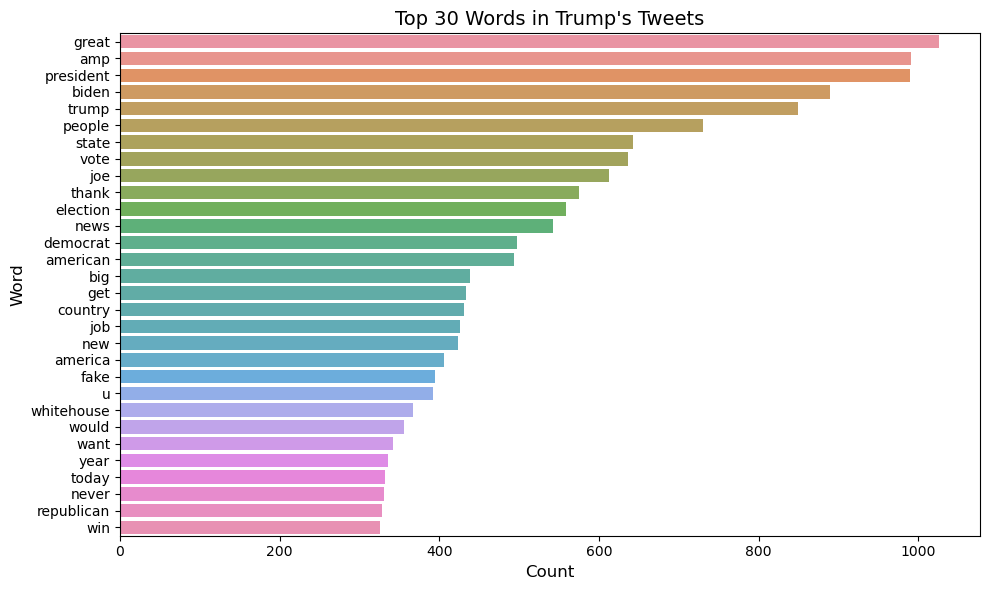

In [8]:
top_30 = value_counts[:30]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_30.values, y=top_30.index, alpha=0.85, palette="husl")
plt.title("Top 30 Words in Trump\'s Tweets", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Word", fontsize=12)
plt.tight_layout()
plt.show()

Despite being a Republican, "democrat" appears among the most frequent terms — more so than "republican." The visualization surfaces the topics and adversarial framing that dominate his public communication style.

---
## Part 3: Named Entity Recognition (NER)

We use spaCy's `en_core_web_sm` model to extract named entities from the lightly cleaned tweet text (`cleaned_text` — before lemmatization/stop word removal, as NER performs best on near-natural-language text).

Entities are grouped into three behavioral categories:

**Organizations** - `ORG` 

**Places** - `GPE` 

**People / Things** - `PERSON`, `NORP`, `FAC`, `LOC`, `PRODUCT`, `EVENT`, `WORK_OF_ART`, `LAW`, `LANGUAGE` 

In [9]:
# Load spaCy English model
nlp = en_core_web_sm.load()

organizations, places, things = [], [], []

for text in df["cleaned_text"].tolist():
    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ == "ORG":
            organizations.append(ent.text)
        elif ent.label_ == "GPE":
            places.append(ent.text)
        elif ent.label_ in [
            "PERSON", "NORP", "FAC", "LOC", "PRODUCT",
            "EVENT", "WORK_OF_ART", "LAW", "LANGUAGE"
        ]:
            things.append(ent.text)

print(f"Organizations: {len(organizations):,}")
print(f"Places       : {len(places):,}")
print(f"Things       : {len(things):,}")

Organizations: 1,586
Places       : 2,997
Things       : 5,293


### Post-NER Cleanup

Some entities are prefixed with `"rt "` (retweet indicator). We strip this prefix before analysis to avoid duplicates.

In [10]:
def remove_rt_prefix(entities: list[str]) -> list[str]:
    """
    Remove 'rt ' prefix from named entity strings (retweet artifact).

    Parameters
    ----------
    entities : list[str]
        Raw extracted entity strings.

    Returns
    -------
    list[str]
        Cleaned entity strings.
    """
    return [e[3:] if e.lower().startswith("rt ") else e for e in entities]

cleaned_orgs   = pd.DataFrame(remove_rt_prefix(organizations), columns=["entity"])
cleaned_places = pd.DataFrame(remove_rt_prefix(places),        columns=["entity"])
cleaned_things = pd.DataFrame(remove_rt_prefix(things),        columns=["entity"])

In [11]:
# Tokenize entities (stop word removal; no lemmatization — see note above)
def process_entities(entity_df: pd.DataFrame) -> list[str]:
    """
    Tokenize and flatten entity strings; strip residual punctuation.

    Parameters
    ----------
    entity_df : pd.DataFrame
        DataFrame with an 'entity' column of entity strings.

    Returns
    -------
    list[str]
        Flat list of cleaned entity tokens.
    """
    tokenized = entity_df["entity"].apply(tokenize_tweet)
    flat = []
    for tokens in tokenized:
        flat.extend([re.sub(r"[^A-Za-z0-9]+", "", t) for t in tokens])
    return [w for w in flat if w.strip()]

orgs_flat   = process_entities(cleaned_orgs)
places_flat = process_entities(cleaned_places)
things_flat = process_entities(cleaned_things)

In [12]:
vc_orgs   = pd.Series(orgs_flat).value_counts()
vc_places = pd.Series(places_flat).value_counts()
vc_things = pd.Series(things_flat).value_counts()

### Top 30 Organizations

/var/folders/jf/v0v68qd97_q0284f80gy8rph0000gn/T/ipykernel_19320/668967026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_orgs[:30].values, y=vc_orgs[:30].index, alpha=0.85, palette="husl")


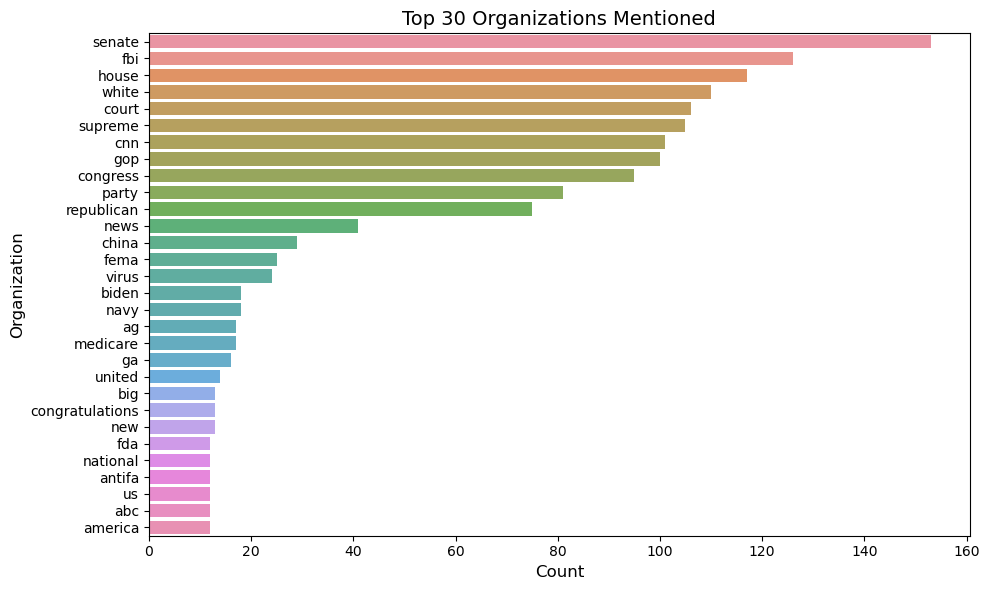

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(x=vc_orgs[:30].values, y=vc_orgs[:30].index, alpha=0.85, palette="husl")
plt.title("Top 30 Organizations Mentioned", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Organization", fontsize=12)
plt.tight_layout()
plt.show()

### Top 30 Places

/var/folders/jf/v0v68qd97_q0284f80gy8rph0000gn/T/ipykernel_19320/1696687342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_places[:30].values, y=vc_places[:30].index, alpha=0.85, palette="husl")


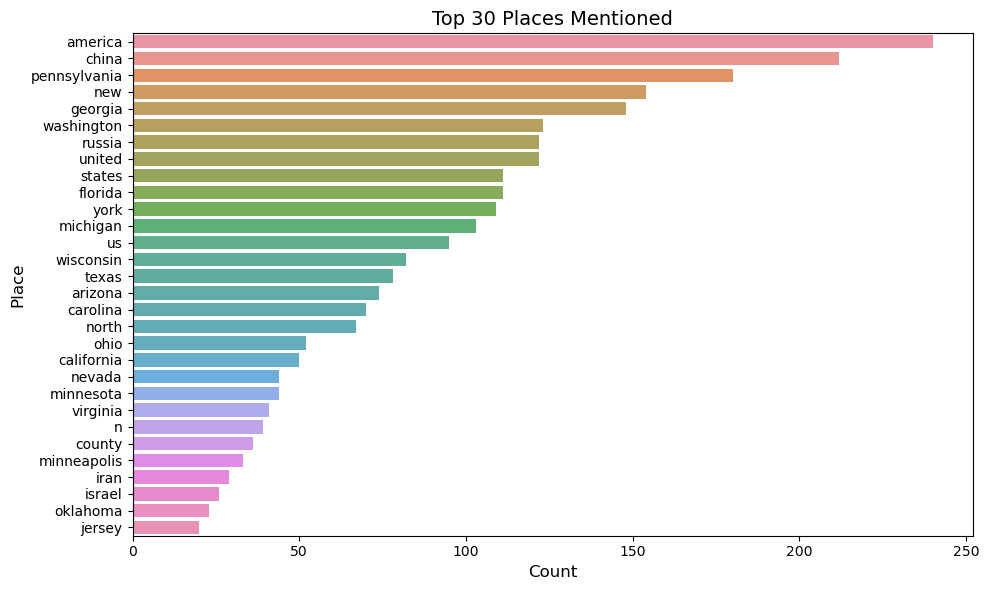

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x=vc_places[:30].values, y=vc_places[:30].index, alpha=0.85, palette="husl")
plt.title("Top 30 Places Mentioned", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Place", fontsize=12)
plt.tight_layout()
plt.show()

### Top 30 People / Things

*"Things" encompasses: people, nationalities, religious/political groups, landmarks, products, events, laws, languages, and creative works.*

/var/folders/jf/v0v68qd97_q0284f80gy8rph0000gn/T/ipykernel_19320/2553125831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_things[:30].values, y=vc_things[:30].index, alpha=0.85, palette="husl")


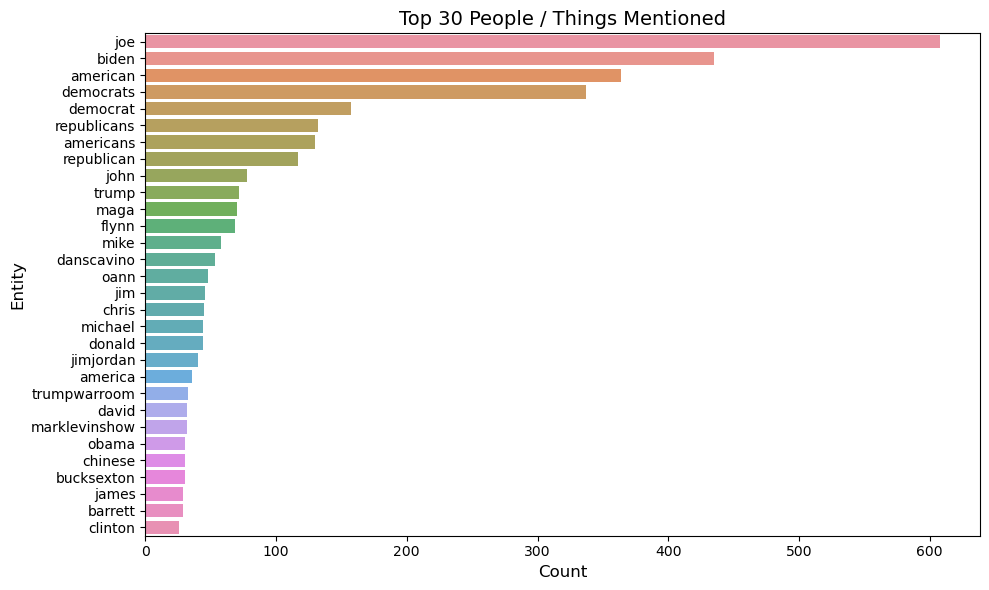

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x=vc_things[:30].values, y=vc_things[:30].index, alpha=0.85, palette="husl")
plt.title("Top 30 People / Things Mentioned", fontsize=14)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Entity", fontsize=12)
plt.tight_layout()
plt.show()

**NER Findings:** The entity breakdowns reveal that Trump's most frequent organizational mentions include the Senate and FBI, his most frequent geographic mentions center on America and China, and his most frequent personal mentions include his Democratic opponent Joe Biden. These entity-level signals provide a quantitative basis for categorizing user content profiles by subject matter and risk-relevant themes.

---
## Part 4: Topic Modeling (LDA via Gensim)

Where word frequency and NER tell us *what* words and entities appear most, LDA discovers **latent topics** — recurring co-occurrence patterns that the model infers without any predefined categories.

We run LDA on our `lemmatized_text` column (already preprocessed) using Gensim.

### Build Dictionary & Corpus

In [16]:
# Filter very short tokens (likely noise)
lda_tokens = [
    [word for word in doc if len(word) > 2]
    for doc in df["lemmatized_text"]
    if isinstance(doc, list)
]

# Build vocabulary: maps each unique word to an integer ID
dictionary = corpora.Dictionary(lda_tokens)

# Filter extremes: remove words in < 5 tweets or > 50% of tweets
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Convert each tweet to bag-of-words format: list of (word_id, frequency) tuples
corpus = [dictionary.doc2bow(doc) for doc in lda_tokens]

print(f"Vocabulary size : {len(dictionary):,}")
print(f"Corpus size     : {len(corpus):,} documents")

Vocabulary size : 3,167
Corpus size     : 10,000 documents


### Train LDA Model

In [17]:
NUM_TOPICS = 6  # Adjust between 5–10 to explore granularity

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,      # More passes → better convergence
    alpha="auto",   # Auto-tune per-document topic distribution
    per_word_topics=True
)

print("Top words per topic:\n")
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}\n")

Top words per topic:

Topic 0: 0.066*"realdonaldtrump" + 0.055*"president" + 0.042*"trump" + 0.020*"whitehouse" + 0.017*"vote" + 0.015*"win" + 0.014*"election" + 0.012*"teamtrump" + 0.011*"coronavirus" + 0.011*"live"

Topic 1: 0.037*"great" + 0.024*"american" + 0.020*"america" + 0.016*"people" + 0.014*"job" + 0.014*"amp" + 0.013*"total" + 0.012*"get" + 0.012*"complete" + 0.011*"endorsement"

Topic 2: 0.014*"new" + 0.013*"governor" + 0.013*"people" + 0.011*"amp" + 0.011*"biden" + 0.010*"ballot" + 0.010*"republican" + 0.010*"covid" + 0.010*"national" + 0.009*"state"

Topic 3: 0.014*"amp" + 0.011*"state" + 0.010*"one" + 0.009*"united" + 0.009*"got" + 0.008*"court" + 0.008*"history" + 0.007*"flynn" + 0.007*"even" + 0.007*"election"

Topic 4: 0.025*"biden" + 0.023*"news" + 0.023*"joe" + 0.020*"fake" + 0.016*"medium" + 0.015*"democrat" + 0.014*"want" + 0.012*"china" + 0.011*"amp" + 0.010*"left"

Topic 5: 0.054*"thank" + 0.031*"great" + 0.018*"order" + 0.015*"maga" + 0.013*"see" + 0.012*"whit

### Visualize Topic Word Distributions

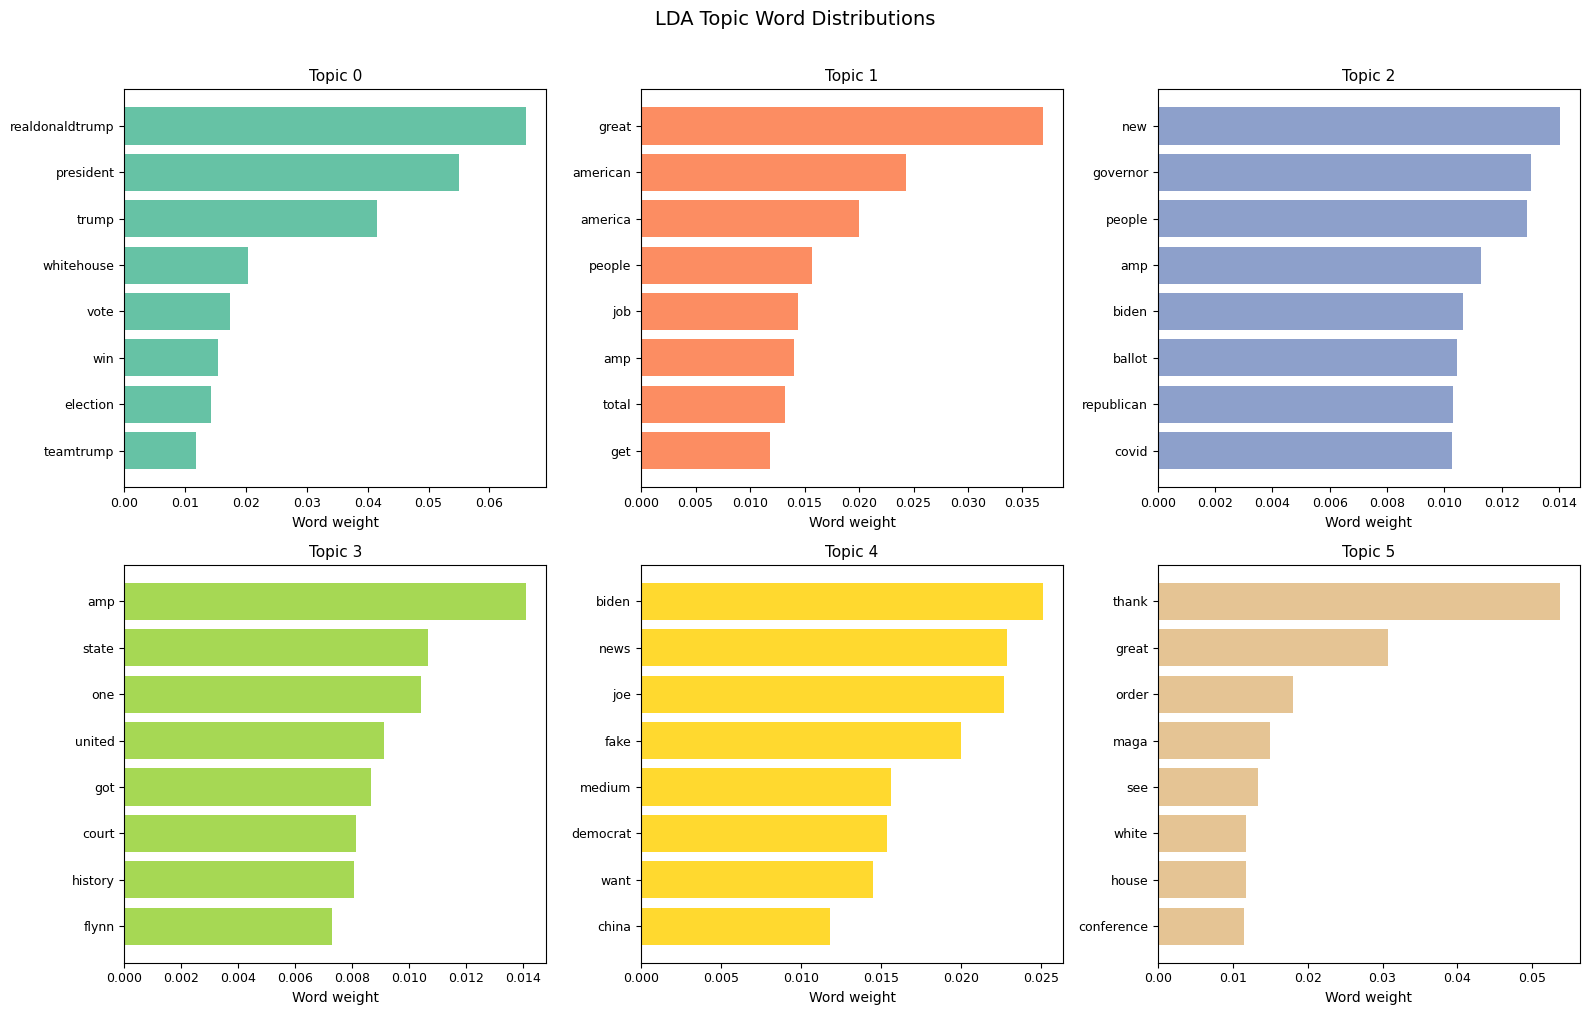

In [18]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("LDA Topic Word Distributions", fontsize=14, y=1.01)

for i in range(NUM_TOPICS):
    ax = fig.add_subplot(2, 3, i + 1)
    top_words = lda_model.show_topic(i, topn=8)
    words, weights = zip(*top_words)

    ax.barh(words[::-1], weights[::-1], color=plt.cm.Set2(i / NUM_TOPICS))
    ax.set_title(f"Topic {i}", fontsize=11)
    ax.set_xlabel("Word weight")
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

### Assign Dominant Topic per Tweet

In [19]:
def get_dominant_topic(bow: list) -> int:
    """
    Return the highest-probability topic index for a given bag-of-words vector.

    Parameters
    ----------
    bow : list
        Bag-of-words representation of a document.

    Returns
    -------
    int
        Dominant topic index, or -1 if no topics are inferred.
    """
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df["dominant_topic"] = [get_dominant_topic(bow) for bow in corpus]

topic_counts = df["dominant_topic"].value_counts().sort_index()
print("Tweet count per dominant topic:")
print(topic_counts)

Tweet count per dominant topic:
dominant_topic
0    2897
1    1620
2     901
3    1616
4    2017
5     949
Name: count, dtype: int64


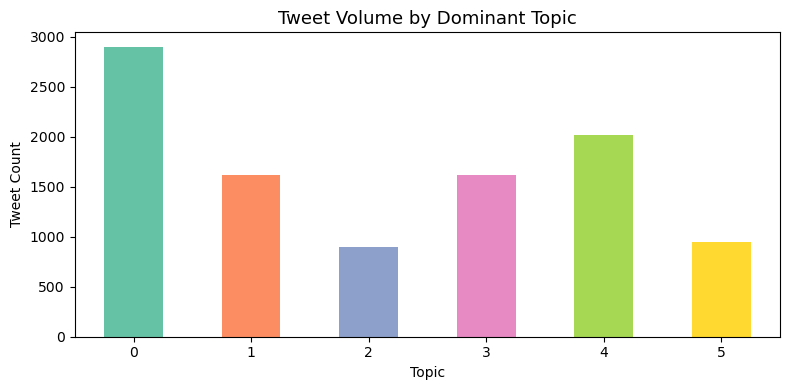

In [20]:
plt.figure(figsize=(8, 4))
topic_counts.plot(kind="bar", color=plt.cm.Set2.colors[:NUM_TOPICS])
plt.title("Tweet Volume by Dominant Topic", fontsize=13)
plt.xlabel("Topic")
plt.ylabel("Tweet Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Topic Modeling Findings

Using LDA with 6 latent topics, the model surfaces distinct discourse clusters across Trump's 10,000 tweets. Topics are characterized by their highest-probability words and loosely correspond to interpretable themes (e.g., political opponents, foreign policy, media criticism, economic messaging).

Each tweet is assigned a dominant topic based on its posterior probability distribution, enabling downstream segmentation of the tweet corpus by subject matter — a scalable approach applicable to any social media content profiling task.

---
## Summary

| Step | Method | Key Output |
|---|---|---|
| Preprocessing | Tokenization, stop word removal, lemmatization | `lemmatized_text` column |
| Word Frequency | Term counts on flattened corpus | Top 30 terms bar chart |
| NER | spaCy `en_core_web_sm` | Top orgs, places, people/things |
| Topic Modeling | LDA (Gensim, 6 topics) | Latent discourse clusters per tweet |

This pipeline demonstrates a scalable framework for extracting behavioral signals from unstructured social media text — applicable to platform safety, content risk assessment, and user profiling contexts.